Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)



Preparing MSW dataset (Forced 6-dim alignment) 
Pre-flight check: Validating MSW CSV mapping...
--- MSW CSV RAW MEANS ---
  > Age     : 62.13
  > Sex     : 0.26
  > Dur     : 8.47
  > LEDD    : 989.80
  > Off-Pre : 45.91
  > On-Pre  : 19.60

Final MSW Breakdown:
 - Unique Subjects on Disk: 111
 - Labeled Responders (1): 61
 - Labeled Non-Responders (0): 5
 - Unlabeled subjects (-1): 45
 - Verified Realized Means (Matched Data Only):
    > Age     : 63.08
    > Sex     : 0.26
    > Dur     : 8.44
    > LEDD    : 1003.95
    > Off-Pre : 45.62
    > On-Pre  : 19.55

❌ FULL MISSING LIST (45 subjects):
  [3, 4, 5, 8, 12, 13, 14, 17, 18, 21, 22, 24, 25, 27, 28, 31, 32, 34, 35, 37, 39, 40, 41, 42, 49, 50, 52, 54, 57, 61, 65, 67, 74, 76, 81, 82, 84, 88, 89, 94, 99, 101, 104, 105, 116]
Loaded cache with 7790 slices.

Preparing CHH dataset (Forced 6-dim alignment) 
Pre-flight check: Validating CHH CSV mapping...
--- CHH CSV RAW MEANS ---
  > Age     : 63.13
  > Sex     : 0.46
  > Dur     : 8.54

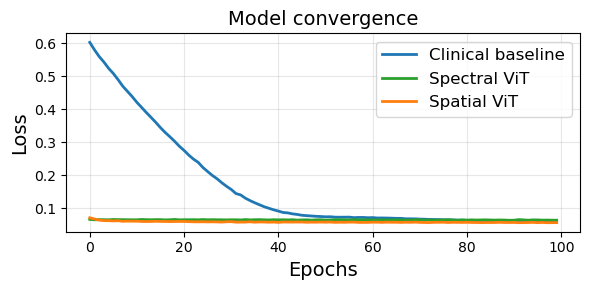

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import transforms
import numpy as np
from sklearnex import patch_sklearn
patch_sklearn()
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, confusion_matrix
from scipy.stats import norm
from statsmodels.stats.contingency_tables import mcnemar
from reader import prepare_qsm_dataset
from util import seed_everything, mask_crop as mask_crop_fn
from train import calibrate_balanced
import matplotlib.pyplot as plt

# Configuration
device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
N_PCA_COMPONENTS = []
N_FOLDS = 5 
NEG_WEIGHT = []
GAMMA = []
EPOCHS = 100
JITTER_STD = 0.1 
TARGET_DIM = 128
IMG_AUG_STD = 0.05
seed_everything(0)

# Statistical helper functions
def delong_roc_test(ground_truth, predictions_one, predictions_two):
    auc1 = roc_auc_score(ground_truth, predictions_one)
    auc2 = roc_auc_score(ground_truth, predictions_two)
    pos_mask, neg_mask = (ground_truth == 1), (ground_truth == 0)
    m, n = np.sum(pos_mask), np.sum(neg_mask)
    def get_components(preds):
        pos_preds, neg_preds = preds[pos_mask], preds[neg_mask]
        v10 = np.array([(np.sum(neg_preds < p) + 0.5 * np.sum(neg_preds == p)) / n for p in pos_preds])
        v01 = np.array([(np.sum(pos_preds > p) + 0.5 * np.sum(pos_preds == p)) / m for p in neg_preds])
        return v10, v01
    v10_1, v01_1 = get_components(predictions_one)
    v10_2, v01_2 = get_components(predictions_two)
    var1 = np.var(v10_1, ddof=1)/m + np.var(v01_1, ddof=1)/n
    var2 = np.var(v10_2, ddof=1)/m + np.var(v01_2, ddof=1)/n
    covariance = np.cov(v10_1, v10_2)[0,1]/m + np.cov(v01_1, v01_2)[0,1]/n
    se = np.sqrt(max(1e-10, var1 + var2 - 2 * covariance))
    z = (auc1 - auc2) / se
    return auc1, auc2, 2 * (1 - norm.cdf(np.abs(z)))

def perform_statistical_tests(y_true, prob_ct, prob_sp, prob_spatial, th_ct, th_sp, th_spatial):
    preds_ct = (prob_ct >= th_ct).astype(int)
    preds_sp = (prob_sp >= th_sp).astype(int)
    preds_spatial = (prob_spatial >= th_spatial).astype(int)
    def get_metrics(p_labels):
        acc = accuracy_score(y_true, p_labels)
        sens = recall_score(y_true, p_labels)
        tn, fp, fn, tp = confusion_matrix(y_true, p_labels, labels=[0, 1]).ravel()
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        return acc, sens, spec
    m_ct, m_sp, m_va = get_metrics(preds_ct), get_metrics(preds_sp), get_metrics(preds_spatial)
    auc_ct, auc_sp, auc_va = roc_auc_score(y_true, prob_ct), roc_auc_score(y_true, prob_sp), roc_auc_score(y_true, prob_spatial)
    def get_p_values(p1, p2, prob1, prob2):
        # Accuracy P-value (McNemar)
        # Where model 1 was correct vs where model 2 was correct
        cm_acc = confusion_matrix(p1 == y_true, p2 == y_true, labels=[0, 1])
        p_acc = mcnemar(cm_acc, exact=True).pvalue
        # Sensitivity P-value (McNemar on Positives)
        pos_idx = (y_true == 1)
        if np.any(pos_idx):
            cm_sens = confusion_matrix(p1[pos_idx] == 1, p2[pos_idx] == 1, labels=[0, 1])
            p_sens = mcnemar(cm_sens, exact=True).pvalue
        else:
            p_sens = np.nan
        # Specificity P-value (McNemar on Negatives)
        neg_idx = (y_true == 0)
        if np.any(neg_idx):
            cm_spec = confusion_matrix(p1[neg_idx] == 0, p2[neg_idx] == 0, labels=[0, 1])
            p_spec = mcnemar(cm_spec, exact=True).pvalue
        else:
            p_spec = np.nan
        # AUC P-value (DeLong)
        if np.array_equal(prob1, prob2):
            p_auc = 1.0
        else:
            try:
                _, _, p_auc = delong_roc_test(y_true, prob1, prob2)
            except:
                p_auc = np.nan
        return p_acc, p_sens, p_spec, p_auc
    p_sp_vs_ct = get_p_values(preds_ct, preds_sp, prob_ct, prob_sp)
    p_va_vs_ct = get_p_values(preds_ct, preds_spatial, prob_ct, prob_spatial)
    p_va_vs_sp = get_p_values(preds_sp, preds_spatial, prob_sp, prob_spatial)
    print(f"\n Model performance \n")
    # Define widths for consistency
    h_w = 22  # Width for the p-value columns to accommodate longer headers
    print(f"{'Metric':<12} | {'Clinical':<8} | {'Spectral':<8} | {'Spatial':<8} | {'p(Spectral, Clinical)':<{h_w}} | {'p(Spatial, Clinical)':<{h_w}} | {'p(Spatial, Spectral)':<{h_w}}")
    print("-" * (12 + 3 + 8 + 3 + 8 + 3 + 8 + 3 + h_w + 3 + h_w + 3 + h_w))
    names = ['Accuracy', 'Sensitivity', 'Specificity', 'AUC']
    v_ct, v_sp, v_va = [*m_ct, auc_ct], [*m_sp, auc_sp], [*m_va, auc_va]
    for i in range(4):
        print(f"{names[i]:<12} | {v_ct[i]:<8.3f} | {v_sp[i]:<8.3f} | {v_va[i]:<8.3f} | {p_sp_vs_ct[i]:<{h_w}.4f} | {p_va_vs_ct[i]:<{h_w}.4f} | {p_va_vs_sp[i]:<{h_w}.4f}")

# Architecture and loss classes
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma
    def forward(self, inputs, targets, weight=None):
        bce = F.binary_cross_entropy(inputs, targets, weight=weight, reduction='none')
        return (self.alpha * (1 - torch.exp(-bce))**self.gamma * bce).mean()

class ClinicalTransformer(nn.Module):
    def __init__(self, n_inputs, embed_dim=32, n_heads=4, n_layers=2):
        super().__init__()
        self.embedding = nn.Linear(1, embed_dim)
        layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=n_heads, dim_feedforward=embed_dim*2, dropout=0.1)
        self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.fc = nn.Linear(embed_dim * n_inputs, 1)
    def forward(self, x, return_logit=False):
        if x.ndim == 1: x = x.unsqueeze(0)
        x = self.embedding(x.unsqueeze(-1)).permute(1, 0, 2)
        x = self.transformer(x).permute(1, 0, 2).flatten(1)
        logit = self.fc(x).squeeze()
        if logit.ndim == 0: logit = logit.unsqueeze(0)
        return logit if return_logit else torch.sigmoid(logit)

class SpectralViT(nn.Module):
    def __init__(self, n_inputs, n_heads=1, embed_dim=32, n_layers=1):
        super().__init__()
        # Initializing weights based on PCA Rank (1/rank)
        ranks = torch.arange(1, n_inputs + 1, dtype=torch.float32)
        self.rank_weights = nn.Parameter(1.0 / ranks)
        # Transformer encoder
        layer = nn.TransformerEncoderLayer(
            d_model=1,           # Each feature is a token
            nhead=n_heads,
            dim_feedforward=embed_dim*2,
            dropout = 0.1)
        self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.fc = nn.Linear(n_inputs, 1)
    def forward(self, x, return_logit=False):
        # Changed torch.exp to linear multiplication
        # Preserves rank-based weighting without saturating gradients.
        x_weighted = x * self.rank_weights
        # Transformer expects (seq_len, batch, feature_dim)
        x_seq = x_weighted.unsqueeze(-1).transpose(0, 1)  # [seq_len, batch, 1]
        x_trans = self.transformer(x_seq)
        x_trans_flat = x_trans.transpose(0, 1).squeeze(-1)  # [batch, n_inputs]
        logit = self.fc(x_trans_flat).squeeze()
        if logit.ndim == 0: logit = logit.unsqueeze(0)
        return logit if return_logit else torch.sigmoid(logit)

class SpatialViT(nn.Module):
    def __init__(self, img_size=128, patch_size=16, embed_dim=32, n_heads=1, n_layers=1):
        super().__init__()
        self.patch_size, self.n_patches = patch_size, (img_size // patch_size) ** 2
        self.proj = nn.Linear(patch_size * patch_size, embed_dim)
        self.pos_embed = nn.Parameter(torch.randn(1, self.n_patches, embed_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=n_heads, dim_feedforward=embed_dim*2, dropout=0.1)
        self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.fc = nn.Linear(embed_dim, 1)
    def forward(self, x, return_logit=False):
        b = x.shape[0]
        x = x.unfold(2, self.patch_size, self.patch_size).unfold(3, self.patch_size, self.patch_size)
        x = self.proj(x.contiguous().view(b, self.n_patches, -1)) + self.pos_embed
        x = self.transformer(x.permute(1, 0, 2)).permute(1, 0, 2).mean(dim=1)
        logit = self.fc(x).squeeze()
        if logit.ndim == 0: logit = logit.unsqueeze(0)
        return logit if return_logit else torch.sigmoid(logit)

class ResidualSpectral(nn.Module):
    def __init__(self, m_ct, m_res):
        super().__init__()
        self.m_ct, self.m_res = m_ct, m_res
    def forward(self, x_res, x_clin, return_logit=False):
        with torch.no_grad(): l_clin = self.m_ct(x_clin, return_logit=True)
        l_res = self.m_res(x_res, return_logit=True)
        joint = l_clin + l_res
        return joint if return_logit else torch.sigmoid(joint)

class ResidualSpatial(nn.Module):
    def __init__(self, m_ct, m_res):
        super().__init__()
        self.m_ct, self.m_res = m_ct, m_res
    def forward(self, x_res, x_clin, return_logit=False):
        with torch.no_grad(): l_clin = self.m_ct(x_clin, return_logit=True)
        l_res = self.m_res(x_res, return_logit=True)
        joint = l_clin + l_res
        return joint if return_logit else torch.sigmoid(joint)

# Data preparation
def robust_flatten(img_np, target_dim=TARGET_DIM):
    t = torch.from_numpy(img_np).float().unsqueeze(0).unsqueeze(0)
    resized = F.interpolate(t, size=(target_dim, target_dim), mode='bilinear', align_corners=False)
    return resized.numpy().flatten()

def get_slice_level_data(dataset, include_unlabeled=False):
    all_imgs, all_clins, all_lbls, subj_map = [], [], [], []
    for i in range(len(dataset)):
        img, clin, lbl, _ = dataset[i]
        if (i % 72) in [0]: continue
        if (lbl != -1) or (include_unlabeled and lbl == -1):
            all_imgs.append(robust_flatten(img.numpy().squeeze()))
            all_clins.append(clin.numpy()); all_lbls.append(lbl); subj_map.append(i)
    return np.array(all_imgs), np.array(all_clins), np.array(all_lbls), np.array(subj_map)

dataset_msw = prepare_qsm_dataset('MSW', '/media/mts_dbs/dbs/all/nii/qsm_115/im', '/media/mts_dbs/dbs/all/nii/seg_ps/', '/data/Ali/RadDBS-QSM/data/docs/dbs_03292024.csv', 'msw_cache_6d_cv.pt', load_cache=True, mask_crop_fn=mask_crop_fn, cv_pad=False)
dataset_chh = prepare_qsm_dataset('CHH', '/media/mts_dbs/chh/nii/qsm/', '/media/mts_dbs/chh/roi/', '/media/mts_dbs/chh/xlsx/chh_subjects_table1_20240729.csv', 'chh_cache_6d_cv.pt', load_cache=True, mask_crop_fn=mask_crop_fn, cv_pad=False)

X_full_slices, X_full_clin, y_full_slices, full_subj_map = get_slice_level_data(dataset_msw, include_unlabeled=True)
labeled_mask = (y_full_slices != -1)
X_tr_slices, X_tr_clin, y_tr_slices, tr_subj_map = X_full_slices[labeled_mask], X_full_clin[labeled_mask], y_full_slices[labeled_mask], full_subj_map[labeled_mask]
NEG_WEIGHT = float(sum(y_tr_slices==1)//sum(y_tr_slices==0))
GAMMA = NEG_WEIGHT
print('Computed negative weight', NEG_WEIGHT, 'by training data class ratio')
X_te_slices, X_te_clin, y_te_slices, te_subj_map = get_slice_level_data(dataset_chh)
img_scaler = StandardScaler().fit(X_tr_slices)

# Cross-validation
unique_subjs = np.unique(tr_subj_map)
y_unique = np.array([y_tr_slices[tr_subj_map == s][0] for s in unique_subjs])
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=0)
fold_preds_ct, fold_preds_sp, fold_preds_spatial = [], [], []
fold_ths_ct, fold_ths_sp, fold_ths_spatial = [], [], []
criterion = FocalLoss(gamma=GAMMA)

# Hyperparameter selection
rng_state = torch.get_rng_state()
pca_components = [16, 32, 64, 128]
component_results = {k: [] for k in pca_components}

# Training
for n_comp in pca_components:    
    # PCA with `n_comp`
    pca_v = PCA(n_components=n_comp, random_state=0, whiten=True).fit(img_scaler.transform(X_tr_slices))
    X_tr_pca_v = pca_v.transform(img_scaler.transform(X_tr_slices))

    # Cross-fold evaluation
    for fold, (t_subj_idx, v_subj_idx) in enumerate(skf.split(unique_subjs, y_unique)):
        # Fold data
        t_idx = np.isin(tr_subj_map, unique_subjs[t_subj_idx])
        v_idx = np.isin(tr_subj_map, unique_subjs[v_subj_idx])
        
        xt_pca_v = torch.tensor(X_tr_pca_v[t_idx], dtype=torch.float32).to(device)
        yt_v = torch.tensor(y_tr_slices[t_idx], dtype=torch.float32).to(device)
        
        # Validation data
        xv_pca_v = torch.tensor(X_tr_pca_v[v_idx], dtype=torch.float32).to(device)
        yv_v = y_tr_slices[v_idx]

        # Model
        m_test = SpectralViT(n_inputs=n_comp).to(device)
        opt_test = optim.Adam(m_test.parameters(), lr=5e-4)
        
        # Train
        for _ in range(int(EPOCHS)):
            m_test.train(); opt_test.zero_grad()
            w = torch.where(yt_v == 0, torch.tensor(NEG_WEIGHT).to(device), torch.tensor(1.0).to(device))
            criterion(m_test(xt_pca_v), yt_v, weight=w).backward()
            opt_test.step()
        
        # 4. Score
        m_test.eval()
        with torch.no_grad():
            v_probs = m_test(xv_pca_v).cpu().numpy()
            # Per-subject mean pooling
            v_subj_probs = []
            v_subj_labels = []
            for s_id in unique_subjs[v_subj_idx]:
                s_mask = (tr_subj_map[v_idx] == s_id)
                v_subj_probs.append(v_probs[s_mask].mean())
                v_subj_labels.append(yv_v[s_mask][0])
            
            fold_auc = roc_auc_score(v_subj_labels, v_subj_probs)
            component_results[n_comp].append(fold_auc)

N_PCA_COMPONENTS = pca_components[np.argmin([np.std(component_results[n]) for n in pca_components])]
print('Selected PCA components', N_PCA_COMPONENTS, 'by cross-validation')

# Cross-validation to find majority class weight
pos_weight_variants = [0.1, 0.25, 0.5, 0.75, 1.0]
weight_results = {k: [] for k in pos_weight_variants}
for p_weight in pos_weight_variants:
    
    for fold, (t_subj_idx, v_subj_idx) in enumerate(skf.split(unique_subjs, y_unique)):
        # Fold mask
        t_mask = np.isin(tr_subj_map, unique_subjs[t_subj_idx])
        v_mask = np.isin(tr_subj_map, unique_subjs[v_subj_idx])
        
        # Scale clinical features
        scaler_weight_test = StandardScaler().fit(X_tr_clin[t_mask])
        xt_c_t = torch.tensor(scaler_weight_test.transform(X_tr_clin[t_mask]), dtype=torch.float32).to(device)
        yt_t = torch.tensor(y_tr_slices[t_mask], dtype=torch.float32).to(device)
        
        # Validation data
        xv_c_v = torch.tensor(scaler_weight_test.transform(X_tr_clin[v_mask]), dtype=torch.float32).to(device)
        yv_v = y_tr_slices[v_mask]

        # Initialize model
        m_weight_test = ClinicalTransformer(n_inputs=X_tr_clin.shape[1]).to(device)
        opt_weight_test = optim.Adam(m_weight_test.parameters(), lr=5e-4)
        
        # Define weight tensor using `NEG_WEIGHT` for class 0 (non-responder), `p_weight` for class 1 (responder)
        w_tensor = torch.where(yt_t == 0, torch.tensor(NEG_WEIGHT).to(device), torch.tensor(p_weight).to(device))
        
        # Train
        for _ in range(int(EPOCHS)):
            m_weight_test.train(); opt_weight_test.zero_grad()
            # Apply Jitter
            x_j = xt_c_t + torch.randn_like(xt_c_t) * JITTER_STD
            criterion(m_weight_test(x_j), yt_t, weight=w_tensor).backward()
            opt_weight_test.step()
        
        # Evaluate
        m_weight_test.eval()
        with torch.no_grad():
            v_probs = m_weight_test(xv_c_v).cpu().numpy()
            v_subj_probs = []
            v_subj_labels = []
            for s_id in unique_subjs[v_subj_idx]:
                s_mask = (tr_subj_map[v_mask] == s_id)
                v_subj_probs.append(v_probs[s_mask].mean())
                v_subj_labels.append(yv_v[s_mask][0])
            
            fold_auc = roc_auc_score(v_subj_labels, v_subj_probs)
            weight_results[p_weight].append(fold_auc)

# Select best weight based on AUC stability
SELECTED_POS_WEIGHT = pos_weight_variants[np.argmin([np.std(weight_results[pw]) for pw in pos_weight_variants])]
print(f"Selected positive weight {SELECTED_POS_WEIGHT} by cross-validation")
torch.set_rng_state(rng_state) 

pca = PCA(n_components=N_PCA_COMPONENTS, random_state=0, whiten=True).fit(img_scaler.transform(X_tr_slices))
X_tr_pca, X_te_pca = pca.transform(img_scaler.transform(X_tr_slices)), pca.transform(img_scaler.transform(X_te_slices))

class PassThrough(nn.Module):
    def forward(self, x, **kwargs): return x

# Loss lists
epochs = 100
all_folds_loss_ct = np.zeros(epochs)
all_folds_loss_sp = np.zeros(epochs)
all_folds_loss_va = np.zeros(epochs)

for fold, (t_subj_idx, v_subj_idx) in enumerate(skf.split(unique_subjs, y_unique)):
    print(f'Fold {fold} Training...')
    t_mask = np.isin(tr_subj_map, unique_subjs[t_subj_idx])
    v_mask = np.isin(tr_subj_map, unique_subjs[v_subj_idx])
    
    scaler_c = StandardScaler().fit(X_tr_clin[t_mask])
    xt_c = torch.tensor(scaler_c.transform(X_tr_clin[t_mask]), dtype=torch.float32).to(device)
    yt = torch.tensor(y_tr_slices[t_mask], dtype=torch.float32).to(device)
    w = torch.where(yt==0, torch.tensor(NEG_WEIGHT).to(device), torch.tensor(SELECTED_POS_WEIGHT).to(device))

    # Clinical transformer
    m_ct = ClinicalTransformer(n_inputs=X_tr_clin.shape[1]).to(device)
    opt_ct = optim.Adam(m_ct.parameters(), lr=1e-4)
    for _ in range(EPOCHS):
        m_ct.train(); opt_ct.zero_grad()
        loss = criterion(m_ct(xt_c + torch.randn_like(xt_c)*JITTER_STD), yt, weight=w)
        loss.backward(); opt_ct.step()
        all_folds_loss_ct[_] += loss.item() / N_FOLDS
    m_ct.eval(); [p.requires_grad_(False) for p in m_ct.parameters()]
    torch.save(m_ct.state_dict(), f'm_ct_fold_{fold}.pth')
    print(f"Saved Clinical Model for Fold {fold}")
    # Spectral ViT
    m_sp = ResidualSpectral(m_ct, SpectralViT(n_inputs=N_PCA_COMPONENTS)).to(device)
    opt_sp = optim.Adam(m_sp.m_res.parameters(), lr=1e-4)
    xt_pca = torch.tensor(X_tr_pca[t_mask], dtype=torch.float32).to(device)
    for _ in range(EPOCHS):
        m_sp.train(); opt_sp.zero_grad()
        p = m_sp(xt_pca + torch.randn_like(xt_pca)*IMG_AUG_STD, xt_c + torch.randn_like(xt_c)*JITTER_STD)
        loss = criterion(p, yt, weight=w)
        loss.backward(); opt_sp.step()
        all_folds_loss_sp[_] += loss.item() / N_FOLDS

    # Spatial ViT
    m_va = ResidualSpatial(m_ct, SpatialViT()).to(device)
    opt_va = optim.Adam(m_va.m_res.parameters(), lr=1e-4)
    xt_img = torch.tensor(X_tr_slices[t_mask]).view(-1, 1, 128, 128).float().to(device)
    for _ in range(EPOCHS):
        m_va.train(); opt_va.zero_grad()
        p = m_va(xt_img + torch.randn_like(xt_img)*IMG_AUG_STD, xt_c + torch.randn_like(xt_c)*JITTER_STD)
        loss = criterion(p, yt, weight=w)
        loss.backward(); opt_va.step()
        all_folds_loss_va[_] += loss.item() / N_FOLDS

    # Balanced accuacy threshold calibration
    m_sp.eval(); m_va.eval()
    with torch.no_grad():
        v_ct, v_sp, v_va, v_lbls = [], [], [], []
        for s_id in unique_subjs[v_subj_idx]:
            sm = (tr_subj_map == s_id)
            c = torch.tensor(scaler_c.transform(X_tr_clin[sm]), dtype=torch.float32).to(device)
            p_in = torch.tensor(X_tr_pca[sm], dtype=torch.float32).to(device)
            i_in = torch.tensor(X_tr_slices[sm]).view(-1, 1, 128, 128).float().to(device)
            v_ct.append(m_ct(c).mean().item())
            v_sp.append(m_sp(p_in, c).mean().item())
            v_va.append(m_va(i_in, c).mean().item())
            v_lbls.append(y_tr_slices[sm][0])
            
    fold_ths_ct.append(calibrate_balanced(PassThrough(), None, np.array(v_ct), np.array(v_lbls), 'cpu'))
    fold_ths_sp.append(calibrate_balanced(PassThrough(), None, np.array(v_sp), np.array(v_lbls), 'cpu'))
    fold_ths_spatial.append(calibrate_balanced(PassThrough(), None, np.array(v_va), np.array(v_lbls), 'cpu'))

    # Inference
    with torch.no_grad():
        t_ct, t_sp, t_va = [], [], []
        for s_id in np.unique(te_subj_map):
            sm = (te_subj_map == s_id)
            c = torch.tensor(scaler_c.transform(X_te_clin[sm]), dtype=torch.float32).to(device)
            p_in = torch.tensor(X_te_pca[sm], dtype=torch.float32).to(device)
            i_in = torch.tensor(X_te_slices[sm]).view(-1, 1, 128, 128).float().to(device)
            t_ct.append(m_ct(c).mean().item()); t_sp.append(m_sp(p_in, c).mean().item()); t_va.append(m_va(i_in, c).mean().item())
        fold_preds_ct.append(t_ct); fold_preds_sp.append(t_sp); fold_preds_spatial.append(t_va)

# Results
y_te_u = np.array([y_te_slices[te_subj_map == s][0] for s in np.unique(te_subj_map)])
p_ct, p_sp, p_va = np.mean(fold_preds_ct, 0), np.mean(fold_preds_sp, 0), np.mean(fold_preds_spatial, 0)
th_ct, th_sp, th_va = np.mean(fold_ths_ct), np.mean(fold_ths_sp), np.mean(fold_ths_spatial)

perform_statistical_tests(y_te_u, p_ct, p_sp, p_va, th_ct, th_sp, th_va)

plt.figure(figsize=(6, 3))
plt.plot(all_folds_loss_ct, label='Clinical baseline', color='tab:blue', linewidth=2)
plt.plot(all_folds_loss_sp, label='Spectral ViT', color='tab:green', linewidth=2)
plt.plot(all_folds_loss_va, label='Spatial ViT', color='tab:orange', linewidth=2)

plt.title('Model convergence', fontsize=14)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [2]:
import gc
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader, TensorDataset, Sampler
from torch.cuda.amp import GradScaler, autocast
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, roc_auc_score

# --- Numerical Stable Focal Loss for AMP ---
def stable_focal_loss(logits, targets, alpha=1, gamma=2):
    """
    Safe for autocast. Uses binary_cross_entropy_with_logits internally.
    """
    bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
    pt = torch.exp(-bce_loss)
    f_loss = alpha * (1 - pt)**gamma * bce_loss
    return f_loss.mean()

# 0. Structural Memory Flush
if 'm_un' in locals(): del m_un
torch.cuda.empty_cache()
gc.collect()

# --- Balanced Sampler: Force 50/50 ratio in every batch ---
class StrictBalancedSampler(Sampler):
    def __init__(self, labels, batch_size=48): # Optimized for 2080 Ti
        self.batch_size = batch_size
        self.neg_indices = np.where(labels == 0)[0]
        self.pos_indices = np.where(labels == 1)[0]
        self.num_batches = len(self.pos_indices) // (batch_size // 2)
        
    def __iter__(self):
        for _ in range(self.num_batches):
            pos_batch = np.random.choice(self.pos_indices, self.batch_size // 2, replace=True)
            neg_batch = np.random.choice(self.neg_indices, self.batch_size // 2, replace=True)
            yield np.concatenate([pos_batch, neg_batch]).tolist()
            
    def __len__(self): return self.num_batches

# --- Attention Gate ---
class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv2d(F_g, F_int, 1), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l, F_int, 1), nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(nn.Conv2d(F_int, 1, 1), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        if g1.shape[2:] != x.shape[2:]:
            g1 = torch.nn.functional.interpolate(g1, size=x.shape[2:], mode='bilinear', align_corners=True)
        x1 = self.W_x(x)
        psi = self.psi(self.relu(g1 + x1))
        return x * psi

# 1. Attention U-Net
class AttentionUNetClassifier(nn.Module):
    def __init__(self, in_channels=1, out_classes=1):
        super().__init__()
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.GroupNorm(2 if out_c <= 16 else 4, out_c),
                nn.Dropout2d(0.2)
            )
        
        self.enc1 = conv_block(in_channels, 16)
        self.enc2 = conv_block(16, 32)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = conv_block(32, 64)
        self.att2 = AttentionGate(64, 32, 32)
        self.att1 = AttentionGate(32, 16, 16)
        self.gap = nn.AdaptiveAvgPool2d(1)
        
        self.fc = nn.Sequential(
            nn.Linear(64 + 32 + 16, 32),
            nn.ReLU(),
            nn.Linear(32, out_classes)
        )
        nn.init.zeros_(self.fc[-1].weight)
        nn.init.zeros_(self.fc[-1].bias)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool(e1)
        e2 = self.enc2(p1)
        p2 = self.pool(e2)
        b = self.bottleneck(p2)
        g2 = self.att2(b, e2)
        g1 = self.att1(g2, e1)
        
        combined = torch.cat([
            self.gap(b).view(b.size(0), -1),
            self.gap(g2).view(g2.size(0), -1),
            self.gap(g1).view(g1.size(0), -1)
        ], dim=1)
        
        return self.fc(combined).squeeze(-1) # Raw logits for stability

# 2. Training Loop
fold_preds_un, fold_ths_un = [], []
all_folds_loss_un = np.zeros(EPOCHS)
scaler = GradScaler() 

for fold, (t_subj_idx, v_subj_idx) in enumerate(skf.split(unique_subjs, y_unique)):
    t_mask = np.isin(tr_subj_map, unique_subjs[t_subj_idx])
    scaler_c = StandardScaler().fit(X_tr_clin[t_mask])
    
    # Data Staging
    xt_i_cpu = torch.tensor(X_tr_slices[t_mask]).view(-1, 1, 128, 128).float()
    yt_cpu = torch.tensor(y_tr_slices[t_mask], dtype=torch.float32)

    m_ct_fold = ClinicalTransformer(n_inputs=X_tr_clin.shape[1]).to(device)
    m_ct_fold.load_state_dict(torch.load(f'm_ct_fold_{fold}.pth', map_location=device))
    m_ct_fold.eval()
    
    with torch.no_grad():
        xt_c_gpu = torch.tensor(scaler_c.transform(X_tr_clin[t_mask]), dtype=torch.float32).to(device)
        t_clin_logits = m_ct_fold(xt_c_gpu, return_logit=True).cpu().detach()
        del xt_c_gpu; torch.cuda.empty_cache()

    train_loader = DataLoader(
        TensorDataset(xt_i_cpu, t_clin_logits, yt_cpu), 
        batch_sampler=StrictBalancedSampler(yt_cpu.numpy(), 48),
        num_workers=4, pin_memory=True 
    )
    
    m_un_res = AttentionUNetClassifier().to(device)
    optimizer = optim.Adam(m_un_res.parameters(), lr=1e-4)

    print(f'Fold {fold} Training | Progress: ', end='')
    for epoch in range(EPOCHS):
        m_un_res.train()
        epoch_loss = 0
        for b_i, b_clin_l, b_y in train_loader:
            b_i = b_i.to(device, non_blocking=True)
            b_clin_l = b_clin_l.to(device, non_blocking=True)
            b_y = b_y.to(device, non_blocking=True)
            
            # --- START OF INTEGRATED STABLE FOCAL LOSS ---
            # Define weights for this batch based on your global settings
            w_batch = torch.where(b_y == 0, 
                                  torch.tensor(NEG_WEIGHT).to(device), 
                                  torch.tensor(SELECTED_POS_WEIGHT).to(device))
            
            optimizer.zero_grad(set_to_none=True)
            with autocast():
                # Forward pass
                res_logit = m_un_res(b_i + torch.randn_like(b_i) * IMG_AUG_STD)
                joint_logit = res_logit + b_clin_l
                
                # Manual focal calculation for stability + parameter matching
                bce_loss = F.binary_cross_entropy_with_logits(joint_logit, b_y, reduction='none')
                pt = torch.exp(-bce_loss)
                f_loss = (1 - pt)**GAMMA * bce_loss # Uses global GAMMA
                loss = (w_batch * f_loss).mean()     # Uses global Weights
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            # --- END OF INTEGRATED STABLE FOCAL LOSS ---
            
            epoch_loss += loss.item()
            
        all_folds_loss_un[epoch] += (epoch_loss / len(train_loader)) / N_FOLDS
        if (epoch + 1) % 10 == 0: print(f'{epoch+1}..', end='')
    print('Done.')

    # Inference logic
    m_un_res.eval()
    with torch.no_grad():
        v_un, v_lbls = [], []
        for s_id in unique_subjs[v_subj_idx]:
            sm = (tr_subj_map == s_id)
            c_v = torch.tensor(scaler_c.transform(X_tr_clin[sm]), dtype=torch.float32).to(device)
            i_v = torch.tensor(X_tr_slices[sm]).view(-1, 1, 128, 128).float().to(device)
            
            l_c = m_ct_fold(c_v, return_logit=True)
            l_s = m_un_res(i_v)
            v_un.append(torch.sigmoid(l_c + l_s).mean().item())
            v_lbls.append(y_tr_slices[sm][0])
            
        fold_ths_un.append(calibrate_balanced(PassThrough(), None, np.array(v_un), np.array(v_lbls), 'cpu'))
        
        t_un = []
        for s_id in np.unique(te_subj_map):
            sm = (te_subj_map == s_id)
            c_t = torch.tensor(scaler_c.transform(X_te_clin[sm]), dtype=torch.float32).to(device)
            i_t = torch.tensor(X_te_slices[sm]).view(-1, 1, 128, 128).float().to(device)
            
            l_c_t = m_ct_fold(c_t, return_logit=True)
            l_s_t = m_un_res(i_t)
            t_un.append(torch.sigmoid(l_c_t + l_s_t).mean().item())
        fold_preds_un.append(t_un)
    torch.save(m_un_res.state_dict(), f'm_un_fold_{fold}.pth')
    # Cleanup VRAM for the next fold
    del m_un_res, m_ct_fold
    torch.cuda.empty_cache()

# 3. Final Metric Call
p_un_avg = np.mean(fold_preds_un, 0)
th_un_avg = np.mean(fold_ths_un)
perform_statistical_tests(y_te_u, p_ct, p_sp, p_un_avg, th_ct, th_sp, th_un_avg)

Fold 0 Training | Progress: 10..20..30..40..50..60..70..80..90..100..Done.
Fold 1 Training | Progress: 10..20..30..40..50..60..70..80..90..100..Done.
Fold 2 Training | Progress: 10..20..30..40..50..60..70..80..90..100..Done.
Fold 3 Training | Progress: 10..20..30..40..50..60..70..80..90..100..Done.
Fold 4 Training | Progress: 10..20..30..40..50..60..70..80..90..100..Done.

 Model performance 

Metric       | Clinical | Spectral | Spatial  | p(Spectral, Clinical)  | p(Spatial, Clinical)   | p(Spatial, Spectral)  
------------------------------------------------------------------------------------------------------------------------
Accuracy     | 0.825    | 0.850    | 0.767    | 0.0000                 | 0.0000                 | 0.0000                
Sensitivity  | 0.838    | 0.838    | 0.765    | 1.0000                 | 0.0000                 | 0.0000                
Specificity  | 0.667    | 1.000    | 0.793    | 0.0000                 | 0.0000                 | 0.0000               

In [3]:
def perform_statistical_tests(y_true, prob_ct, prob_sp, prob_svit, prob_unet, th_ct, th_sp, th_svit, th_unet):
    # 1. Generate Hard Predictions
    preds_ct = (prob_ct >= th_ct).astype(int)
    preds_sp = (prob_sp >= th_sp).astype(int)
    preds_svit = (prob_svit >= th_svit).astype(int)
    preds_unet = (prob_unet >= th_unet).astype(int)

    def get_metrics(p_labels, probs):
        acc = accuracy_score(y_true, p_labels)
        sens = recall_score(y_true, p_labels)
        tn, fp, fn, tp = confusion_matrix(y_true, p_labels, labels=[0, 1]).ravel()
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        auc = roc_auc_score(y_true, probs)
        return [acc, sens, spec, auc]

    # Calculate metrics
    m_ct = get_metrics(preds_ct, prob_ct)
    m_sp = get_metrics(preds_sp, prob_sp)
    m_svit = get_metrics(preds_svit, prob_svit)
    m_unet = get_metrics(preds_unet, prob_unet)

    def get_p_vs_spectral(p_target, prob_target):
        """Calculates McNemar (Acc) and DeLong (AUC) vs Spectral ViT"""
        # Accuracy P-value (McNemar)
        cm = confusion_matrix(preds_sp == y_true, p_target == y_true, labels=[0, 1])
        p_acc = mcnemar(cm, exact=True).pvalue
        # AUC P-value (DeLong)
        _, _, p_auc = delong_roc_test(y_true, prob_sp, prob_target)
        return p_acc, p_auc

    # Comparisons: All models relative to Spectral ViT
    p_ct_vs_sp = get_p_vs_spectral(preds_ct, prob_ct)
    p_svit_vs_sp = get_p_vs_spectral(preds_svit, prob_svit)
    p_unet_vs_sp = get_p_vs_spectral(preds_unet, prob_unet)

    # --- Print Professional Table ---
    print(f"\n{'='*115}")
    print(f"{'Metric':<12} | {'Clinical Tx':<12} | {'Spectral ViT':<12} | {'Spatial ViT':<12} | {'U-net Attn':<12}")
    print(f"{'-'*115}")
    
    names = ['Accuracy', 'Sensitivity', 'Specificity', 'AUC']
    rows = [m_ct, m_sp, m_svit, m_unet]
    
    for i in range(4):
        print(f"{names[i]:<12} | {m_ct[i]:<12.3f} | {m_sp[i]:<12.3f} | {m_svit[i]:<12.3f} | {m_unet[i]:<12.3f}")
    
    print(f"{'='*115}")
    print(f"\nStatistical Significance (Relative to Spectral ViT):")
    print(f"{'Comparison':<30} | {'Acc p-val':<12} | {'AUC p-val':<12}")
    print(f"{'-'*60}")
    print(f"{'Clinical Tx vs Spectral':<30} | {p_ct_vs_sp[0]:<12.4f} | {p_ct_vs_sp[1]:<12.4f}")
    print(f"{'Spatial ViT vs Spectral':<30} | {p_svit_vs_sp[0]:<12.4f} | {p_svit_vs_sp[1]:<12.4f}")
    print(f"{'U-net Attn vs Spectral':<30} | {p_unet_vs_sp[0]:<12.4f} | {p_unet_vs_sp[1]:<12.4f}")

# Assuming p_un_avg and th_un_avg are the results from your U-net with attention loop
perform_statistical_tests(
    y_te_u, 
    p_ct,          # Clinical Transformer
    p_sp,          # Spectral ViT (Baseline)
    p_va,          # Spatial ViT
    p_un_avg,      # U-net with Attention
    th_ct, th_sp, th_va, th_un_avg
)


Metric       | Clinical Tx  | Spectral ViT | Spatial ViT  | U-net Attn  
-------------------------------------------------------------------------------------------------------------------
Accuracy     | 0.825        | 0.850        | 0.802        | 0.767       
Sensitivity  | 0.838        | 0.838        | 0.798        | 0.765       
Specificity  | 0.667        | 1.000        | 0.854        | 0.793       
AUC          | 0.901        | 0.910        | 0.885        | 0.868       

Statistical Significance (Relative to Spectral ViT):
Comparison                     | Acc p-val    | AUC p-val   
------------------------------------------------------------
Clinical Tx vs Spectral        | 0.0000       | 0.0000      
Spatial ViT vs Spectral        | 0.0000       | 0.0000      
U-net Attn vs Spectral         | 0.0000       | 0.0000      


In [4]:
from sklearn.linear_model import LogisticRegression

# 1. Model Definition for PCA+Clinical MLP
class PCAClinMLP(nn.Module):
    def __init__(self, n_inputs):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_inputs, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x, return_logit=False):
        logit = self.net(x).squeeze()
        if logit.ndim == 0: logit = logit.unsqueeze(0)
        return logit if return_logit else torch.sigmoid(logit)

# Initialize storage
fold_preds_mlp, fold_preds_lr = [], []
fold_ths_mlp, fold_ths_lr = [], []

for fold, (t_subj_idx, v_subj_idx) in enumerate(skf.split(unique_subjs, y_unique)):
    print(f'Fold {fold} Training Pure Baselines (Concatenated PCA + Clinical)...')
    t_mask = np.isin(tr_subj_map, unique_subjs[t_subj_idx])
    
    # 2. Prepare Concatenated Inputs
    scaler_c = StandardScaler().fit(X_tr_clin[t_mask])
    
    # Training set
    X_tr_clin_scaled = scaler_c.transform(X_tr_clin[t_mask])
    # Concatenate PCA and Clinical: Shape [N_slices, N_PCA + N_Clin]
    X_tr_combined = np.hstack([X_tr_pca[t_mask], X_tr_clin_scaled])
    
    yt = torch.tensor(y_tr_slices[t_mask], dtype=torch.float32).to(device)
    xt_combined = torch.tensor(X_tr_combined, dtype=torch.float32).to(device)
    w = torch.where(yt==0, torch.tensor(NEG_WEIGHT).to(device), torch.tensor(SELECTED_POS_WEIGHT).to(device))

    # --- 1. Logistic Regression (Scratch) ---
    clf_lr = LogisticRegression(class_weight='balanced', max_iter=1000)
    clf_lr.fit(X_tr_combined, y_tr_slices[t_mask])
    
    # --- 2. PCA + MLP (Scratch) ---
    m_mlp = PCAClinMLP(n_inputs=X_tr_combined.shape[1]).to(device)
    opt_mlp = optim.Adam(m_mlp.parameters(), lr=1e-4)
    
    for _ in range(EPOCHS):
        m_mlp.train(); opt_mlp.zero_grad()
        # Adding noise only to the PCA/feature part if desired, or whole vector
        noise = torch.randn_like(xt_combined) * IMG_AUG_STD
        loss = criterion(m_mlp(xt_combined + noise), yt, weight=w)
        loss.backward(); opt_mlp.step()

    # --- 3. Calibration & Inference ---
    m_mlp.eval()
    with torch.no_grad():
        v_mlp, v_lr, v_lbls = [], [], []
        for s_id in unique_subjs[v_subj_idx]:
            sm = (tr_subj_map == s_id)
            # Prep validation features
            v_clin_scaled = scaler_c.transform(X_tr_clin[sm])
            v_combined = np.hstack([X_tr_pca[sm], v_clin_scaled])
            v_comb_torch = torch.tensor(v_combined, dtype=torch.float32).to(device)
            
            # MLP Prediction
            v_mlp.append(m_mlp(v_comb_torch).mean().item())
            # LR Prediction
            v_lr.append(clf_lr.predict_proba(v_combined)[:, 1].mean())
            v_lbls.append(y_tr_slices[sm][0])

        fold_ths_mlp.append(calibrate_balanced(PassThrough(), None, np.array(v_mlp), np.array(v_lbls), 'cpu'))
        fold_ths_lr.append(calibrate_balanced(PassThrough(), None, np.array(v_lr), np.array(v_lbls), 'cpu'))

        # Test Set Inference
        t_mlp_subj, t_lr_subj = [], []
        for s_id in np.unique(te_subj_map):
            sm = (te_subj_map == s_id)
            # Prep test features
            te_clin_scaled = scaler_c.transform(X_te_clin[sm])
            te_combined = np.hstack([X_te_pca[sm], te_clin_scaled])
            te_comb_torch = torch.tensor(te_combined, dtype=torch.float32).to(device)
            
            t_mlp_subj.append(m_mlp(te_comb_torch).mean().item())
            t_lr_subj.append(clf_lr.predict_proba(te_combined)[:, 1].mean())
            
        fold_preds_mlp.append(t_mlp_subj)
        fold_preds_lr.append(t_lr_subj)

# Calculate final averages
p_mlp = np.mean(fold_preds_mlp, 0)
p_lr = np.mean(fold_preds_lr, 0)
th_mlp = np.mean(fold_ths_mlp)
th_lr = np.mean(fold_ths_lr)

print("Pure baseline training complete. Models trained on concatenated PCA + Clinical features.")

Fold 0 Training Pure Baselines (Concatenated PCA + Clinical)...
Fold 1 Training Pure Baselines (Concatenated PCA + Clinical)...
Fold 2 Training Pure Baselines (Concatenated PCA + Clinical)...
Fold 3 Training Pure Baselines (Concatenated PCA + Clinical)...
Fold 4 Training Pure Baselines (Concatenated PCA + Clinical)...
Pure baseline training complete. Models trained on concatenated PCA + Clinical features.


In [5]:
def perform_final_master_stats(y_true, model_configs, baseline_idx=3):
    """
    model_configs: List of tuples (Name, Probs, Threshold)
    baseline_idx: Index of the model to compare others against
    """
    results = []
    
    # 1. Compute basic metrics for all models
    for name, prob, th in model_configs:
        preds = (prob >= th).astype(int)
        acc = accuracy_score(y_true, preds)
        sens = recall_score(y_true, preds)
        tn, fp, fn, tp = confusion_matrix(y_true, preds, labels=[0, 1]).ravel()
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        auc = roc_auc_score(y_true, prob)
        
        results.append({
            'name': name,
            'metrics': [acc, sens, spec, auc],
            'preds': preds,
            'probs': prob
        })

    # 2. Set the reference (Spectral ViT)
    base = results[baseline_idx]
    
    print(f"\n{'='*110}")
    print(f"{'MASTER MODEL COMPARISON (Baseline: ' + base['name'] + ')':^110}")
    print(f"{'='*110}")
    print(f"{'Model Name':<18} | {'Acc':<6} | {'Sens':<6} | {'Spec':<6} | {'AUC':<6} | {'p-val (Acc)':<12} | {'p-val (AUC)':<12}")
    print(f"{'-'*110}")
    
    for i, res in enumerate(results):
        # Statistical Tests vs. Baseline
        if i == baseline_idx:
            p_acc_str = "---"
            p_auc_str = "---"
        else:
            # McNemar for Accuracy
            cm = confusion_matrix(res['preds'] == y_true, base['preds'] == y_true, labels=[0, 1])
            p_acc = mcnemar(cm, exact=True).pvalue
            p_acc_str = f"{p_acc:.4f}"
            
            # DeLong for AUC
            try:
                _, _, p_auc = delong_roc_test(y_true, res['probs'], base['probs'])
                p_auc_str = f"{p_auc:.4f}"
            except:
                p_auc_str = "NaN"
        
        m = res['metrics']
        print(f"{res['name']:<18} | {m[0]:.3f}  | {m[1]:.3f}  | {m[2]:.3f}  | {m[3]:.3f}  | {p_acc_str:<12} | {p_auc_str:<12}")
    
    print(f"{'='*110}")

# --- Execute Comparison ---
# Order: Logit, MLP, Clinical, Spectral (Baseline), Spatial, U-Net
all_models = [
    ("Logit Reg", p_lr, th_lr),
    ("PCA+MLP", p_mlp, th_mlp),
    ("Clinical Tx", p_ct, th_ct),
    ("Spectral ViT", p_sp, th_sp),
    ("Spatial ViT", p_va, th_va),
    ("U-net Attn", p_un_avg, th_un_avg)
]

perform_final_master_stats(y_te_u, all_models, baseline_idx=3)


                               MASTER MODEL COMPARISON (Baseline: Spectral ViT)                               
Model Name         | Acc    | Sens   | Spec   | AUC    | p-val (Acc)  | p-val (AUC) 
--------------------------------------------------------------------------------------------------------------
Logit Reg          | 0.795  | 0.829  | 0.385  | 0.673  | 0.0000       | 0.0000      
PCA+MLP            | 0.662  | 0.686  | 0.362  | 0.578  | 0.0000       | 0.0000      
Clinical Tx        | 0.825  | 0.838  | 0.667  | 0.901  | 0.0000       | 0.0000      
Spectral ViT       | 0.850  | 0.838  | 1.000  | 0.910  | ---          | ---         
Spatial ViT        | 0.802  | 0.798  | 0.854  | 0.885  | 0.0000       | 0.0000      
U-net Attn         | 0.767  | 0.765  | 0.793  | 0.868  | 0.0000       | 0.0000      


U-Net weights loaded successfully.


/data/Ali/anaconda3/envs/dpeekenv/lib/python3.8/site-packages/torch/nn/functional.py:3454: UserWarning: Default upsampling behavior when mode=bilinear is changed to align_corners=False since 0.4.0. Please specify align_corners=True if the old behavior is desired. See the documentation of nn.Upsample for details.
  warnings.warn(


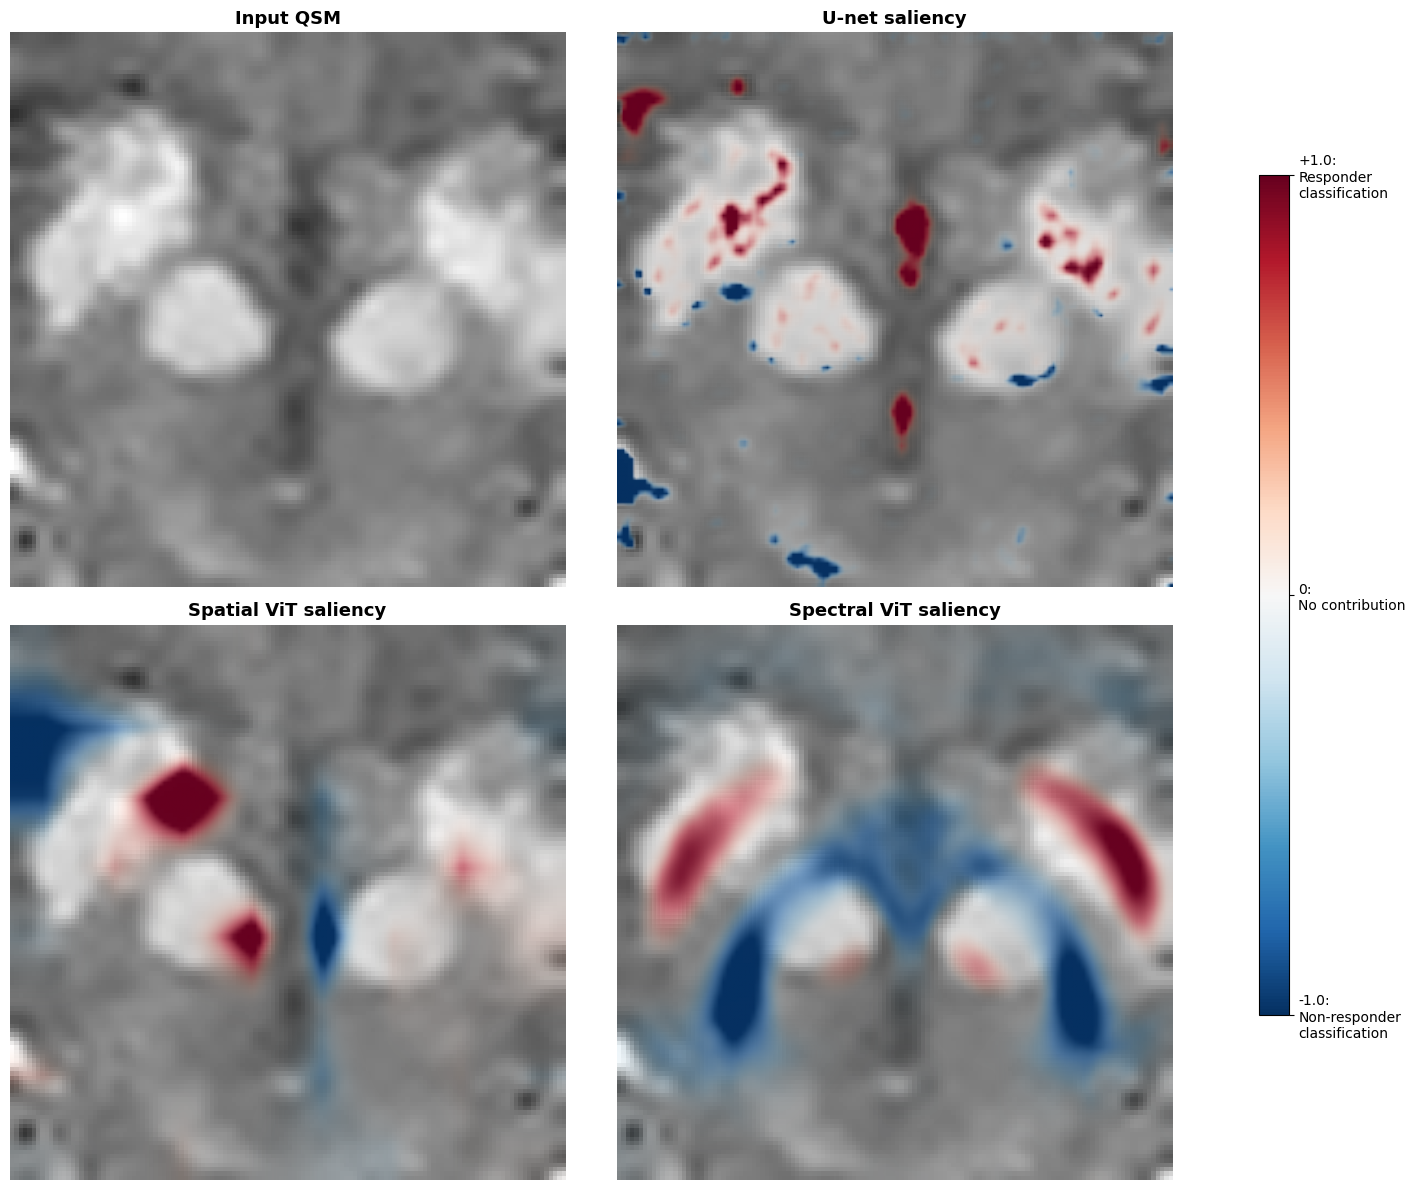

In [6]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter
import torch.nn.functional as F

# 1. Ensure the U-Net is available (Re-instantiate and load if needed)
# Assuming device and AttentionUNetClassifier are defined in previous cells
m_un_res = AttentionUNetClassifier().to(device)
try:
    # Loading weights from the final fold to ensure the model is trained
    m_un_res.load_state_dict(torch.load('m_un_fold_4.pth', map_location=device))
    print("U-Net weights loaded successfully.")
except:
    print("U-Net weights not found; using current state.")

def viz_shared_scale(pca_model, m_sp, m_va, m_un, X_te_raw, X_te_pca, X_te_clin, scaler_c):
    m_sp.eval(); m_va.eval(); m_un.eval()
    device = next(m_sp.parameters()).device
    idx = 40 

    # --- Data preparation ---
    xp_t = torch.from_numpy(X_te_pca[idx:idx+1]).float().to(device).requires_grad_(True)
    xi_t = torch.from_numpy(X_te_raw[idx:idx+1]).view(-1, 1, 128, 128).float().to(device).requires_grad_(True)

    # --- Saliency Computations ---
    m_un.zero_grad()
    logits = m_un(xi_t)
    grad_un = torch.autograd.grad(logits[0], xi_t)[0]
    unet_raw = (grad_un * xi_t).detach().cpu().numpy().squeeze()
    unet_map = gaussian_filter(unet_raw, sigma=1.0) 

    raw_w = m_sp.m_res.fc.weight.detach().cpu().numpy().squeeze()
    rank_w = m_sp.m_res.rank_weights.detach().cpu().numpy()
    pca_sal = raw_w * rank_w * xp_t.detach().cpu().numpy().squeeze()
    spec_map = np.zeros((128, 128))
    for i in range(len(pca_sal)):
        spec_map += pca_sal[i] * pca_model.components_[i].reshape(128, 128)
    
    with torch.no_grad():
        b, p_size, n_p = xi_t.shape[0], m_va.m_res.patch_size, m_va.m_res.n_patches
        x_p = xi_t.unfold(2, p_size, p_size).unfold(3, p_size, p_size)
        x_p = m_va.m_res.proj(x_p.contiguous().view(b, n_p, -1)) + m_va.m_res.pos_embed
        _, attn_weights = m_va.m_res.transformer.layers[-1].self_attn(x_p.permute(1, 0, 2), x_p.permute(1, 0, 2), x_p.permute(1, 0, 2))
        spat_attn = attn_weights.mean(dim=1).view(b, int(np.sqrt(n_p)), int(np.sqrt(n_p)))
        spat_map = F.interpolate(spat_attn.unsqueeze(1), size=(128, 128), mode='bilinear').squeeze().cpu().numpy()
        spat_map -= spat_map.mean()

    # --- INDEPENDENT POLAR NORMALIZATION ---
    def independent_polar_norm(img, p=98.0):
        pos_m, neg_m = img > 0, img < 0
        v_max = np.percentile(img[pos_m], p) if np.any(pos_m) else 1e-12
        v_min = np.percentile(img[neg_m], 100-p) if np.any(neg_m) else -1e-12
        normed = np.zeros_like(img)
        normed[pos_m] = img[pos_m] / v_max
        normed[neg_m] = -img[neg_m] / v_min 
        return np.clip(normed, -1, 1)

    spec_normed = independent_polar_norm(spec_map)
    spat_normed = independent_polar_norm(spat_map)
    unet_normed = independent_polar_norm(unet_map)

    # --- COLOR RENDERING ---
    fig, axes = plt.subplots(2, 2, figsize=(15, 12), facecolor='white')
    bg = np.rot90(X_te_raw[idx].reshape(128, 128), k=1)
    cmap = plt.get_cmap("RdBu_r")
    norm = mcolors.Normalize(vmin=-1, vmax=1)

    def plot_shared(ax, data, title, overlay_sigma=0.3, power=2.5):
        data_rot = np.rot90(data, k=1)
        ax.imshow(bg, cmap='gray', vmin=-1, vmax=1) 
        rgba = cmap(norm(data_rot))
        intensity = np.abs(data_rot)
        alpha = np.power(intensity, power)
        if overlay_sigma > 0:
            alpha = gaussian_filter(alpha, sigma=overlay_sigma)
        rgba[:, :, 3] = np.clip(alpha, 0, 1)
        ax.imshow(rgba, interpolation='bilinear')
        ax.set_title(title, fontweight='bold', fontsize=13)
        ax.axis('off')

    # Rendering
    axes[0, 0].imshow(bg, cmap='gray', vmin=-1, vmax=1); axes[0, 0].axis('off')
    axes[0, 0].set_title("Input QSM", fontweight='bold', fontsize=13)

    plot_shared(axes[0, 1], unet_normed, "U-net saliency", overlay_sigma=0.3, power=2.5)
    plot_shared(axes[1, 0], spat_normed, "Spatial ViT saliency", overlay_sigma=0.3, power=2.5)
    plot_shared(axes[1, 1], spec_normed, "Spectral ViT saliency", overlay_sigma=0.3, power=2.5)

    # Tight layout first to clean up standard padding
    plt.tight_layout()
    
    # --- ADJUSTING COLUMN SPACE ---
    # wspace adds horizontal padding between subplots
    # right=0.8 leaves room for the colorbar
    fig.subplots_adjust(wspace=0.05, right=0.8) 
    
    # --- COLORBAR ---
    cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7]) 
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_ticks([-1, 0, 1])
    cbar.set_ticklabels([
        '-1.0:\nNon-responder\nclassification', 
        '0:\nNo contribution', 
        '+1.0:\nResponder\nclassification'
    ])
    cbar.ax.tick_params(labelsize=10)

    plt.show()

viz_shared_scale(pca, m_sp, m_va, m_un_res, X_te_slices, X_te_pca, X_te_clin, scaler_c)